# DCM Analysis

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import sys
sys.path.append('../')
import amglib.readers as rd
import amglib.dcm_reduction as dcm

## Load data

In [5]:
base_path = '/Users/Shared/Data/P20250738_1_Dagger/02_rawdata/'

### Load meta data
Getting proton current (exp_avg) and wavelength (L)

In [12]:
def str2float(x) :
    res = np.zeros(len(x))
    for i in range(len(x)) :
        res[i]=x[i].split(' ')[0]
        
    return res

In [25]:
N=453
meta = rd.read_fits_meta_data2(base_path+'02_ReferenceScan/refs_{0:05d}.fits',first=1,last=2*N,parlist=['HIERARCH detector_phys/exp_avg','HIERARCH double_cristal_mono/dcm_lambda'])

exp_avg = str2float(meta['HIERARCH detector_phys/exp_avg'])
L       = str2float(meta['HIERARCH double_cristal_mono/dcm_lambda'])

In [26]:
L[(2*N-5):]

array([4.98, 4.98, 5.  , 5.  , 5.  ])

### Load and prepare DC
In this case we use the ob with parallel crystals to get instrument background.

In [28]:
N=20
dc = rd.read_images(base_path+'01_DC/ob_th0-02/ob_th0_{0:05d}.fits',first=1,last=N)

  0%|          | 0/20 [00:00<?, ?it/s]

In [29]:
dc = dcm.reduce_measurements(dc)

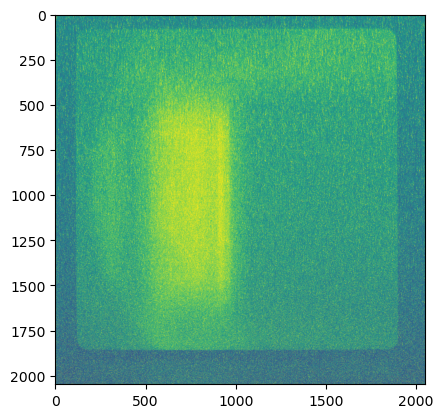

In [32]:
plt.imshow(dc,vmin=280,vmax=400)

### Load ob and Fe scans

In [33]:
N=453
img0 = rd.read_images(base_path+'02_ReferenceScan/refs_{0:05d}.fits',first=1,last=2*N)

  0%|          | 0/906 [00:00<?, ?it/s]

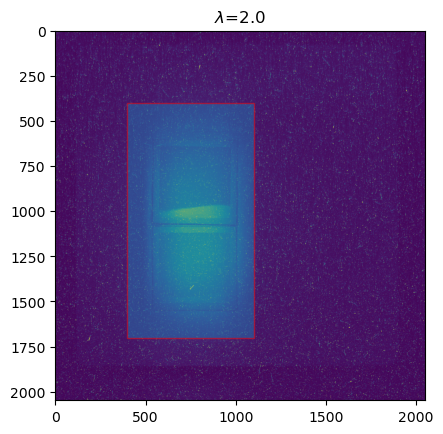

In [62]:
i = N
roi = [400,400,1100,1700]
plt.imshow(img0[i],vmin = 300, vmax=1500)
R = patches.Rectangle(xy=(roi[0],roi[1]),width=roi[2]-roi[0],height=roi[3]-roi[1],ec='red',alpha=0.5)
plt.gca().add_patch(R)
plt.title(r'$\lambda$={0}'.format(L[i]));

In [91]:
ob = dcm.reduce_repeated_measurements(img0[0:N,roi[1]:roi[3],roi[0]:roi[2]],Nrepeats=3,th=1)

In [92]:
img = dcm.reduce_repeated_measurements(img0[N:,roi[1]:roi[3],roi[0]:roi[2]],Nrepeats=3,th=1)

In [93]:
nimg = dcm.normalize_data(img,ob,dc[roi[1]:roi[3],roi[0]:roi[2]],dose=np.array([1200,300,1240,400]))

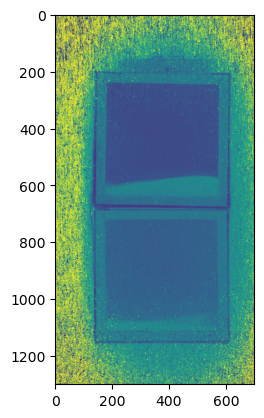

In [94]:
plt.imshow(nimg[0],vmin=0,vmax=2)

Text(0.5, 0, '$\\lambda$ [Å]')

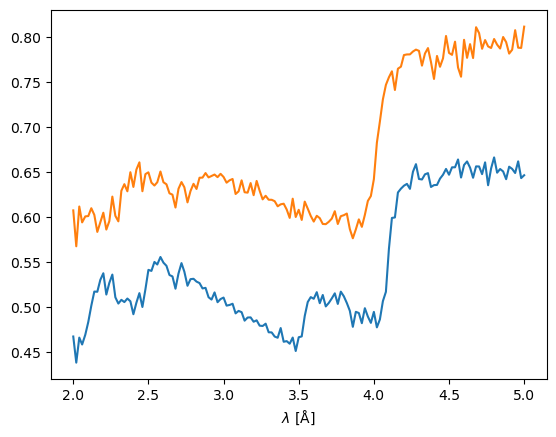

In [95]:
plt.plot(L[:N:3],nimg[:,300:500,300:500].mean(axis=(1,2)))
plt.plot(L[:N:3],nimg[:,800:1000,300:500].mean(axis=(1,2)))
plt.xlabel(r"$\lambda$ [Å]")

In [90]:
img0.shape

(906, 2048, 2048)

In [135]:
import matplotlib.patches as patches

def plot_profiles(x, L, rois, labels = None, figsize = None, vmin=None, vmax=None,cmap='viridis') :
    if figsize is None:
        figsize = [12,5]
        
    fig,ax = plt.subplots(1,2,figsize=figsize)
    
    ax[0].imshow(x.mean(axis=0),vmin=vmin,vmax=vmax)
    
    cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    if type(rois[0]) is list :
        for idx,roi in enumerate(rois) :
            
            R = patches.Rectangle(xy=(roi[0],roi[1]),width=roi[2]-roi[0],height=roi[3]-roi[1],ec=cycle[idx],alpha=0.5)
            ax[0].add_patch(R)
            
            if labels is not None :
                label = labels[idx]
            else :
                label = None
            ax[1].plot(L,x[:,roi[1]:roi[3],roi[0]:roi[2]].mean(axis=(1,2)),label=label,cmap=cmap)
        if labels is not None :
            ax[1].legend()

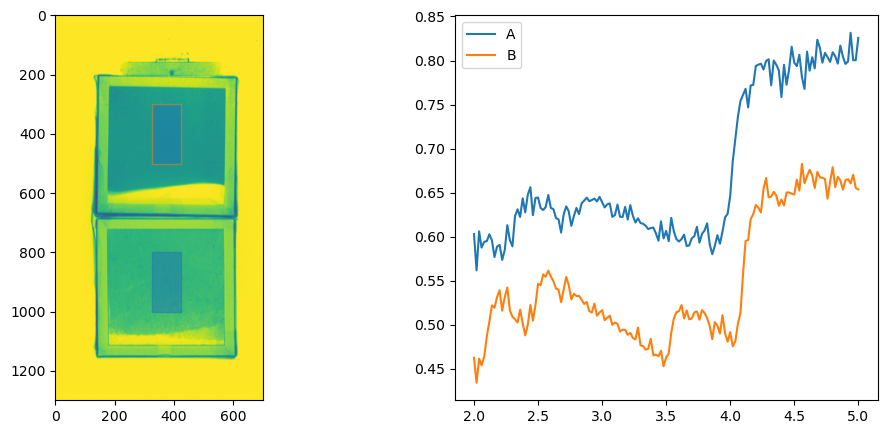

In [137]:
plot_profiles(nimg,L=L[:N:3],rois=[[325,800,425,1000],[325,300,425,500]],vmin=0,vmax=1,labels=['A','B'])

In [100]:
w

array([[1, 2, 3],
       [4, 5, 6]])

In [101]:
w2

array([[1, 2, 3],
       [4, 5, 6]])

In [102]:
for ww in w :
    print(w)

[[1 2 3]
 [4 5 6]]
[[1 2 3]
 [4 5 6]]


In [104]:
type(q)

list

In [108]:
if type(q[0]) is list :
    print('l')

l
